In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

In [12]:
# Считаем данные
df = pd.read_csv('features/features_one_week.csv', sep=';')
df.shape

(2496011, 20)

In [13]:
df.columns

Index(['НеделяНачало', 'КодТовара', 'Номенклатура', 'Папка1', 'Папка2',
       'Количество', 'Розничная30%', 'ЕдиницаИзмерения', 'ТоварнаяКатегория',
       'Поставщик', 'ЗакупочнаяЦена', 'ДатаПоследнегоПоступления',
       'ОстатокНачалоНедели', 'temp_mean_week', 'precip_sum_week',
       'temp_max_week', 'temp_min_week', 'НДС', 'days_off_in_week',
       'sales_lag_2w'],
      dtype='object')

In [14]:
df.head()

,НеделяНачало,КодТовара,Номенклатура,Папка1,Папка2,Количество,Розничная30%,ЕдиницаИзмерения,ТоварнаяКатегория,Поставщик,ЗакупочнаяЦена,ДатаПоследнегоПоступления,ОстатокНачалоНедели,temp_mean_week,precip_sum_week,temp_max_week,temp_min_week,НДС,days_off_in_week,sales_lag_2w
0,2017-04-10,00-00000030,Биогумус Флорист Бутон 120мл.,01 Химия для сада и огорода,"01 Жидкие удобрения, стимуляторы, подкормки",0.0,62.0,шт,Штучный товар,Неизвестный поставщик,47.34,2017-04-02 12:00:00,10.0,6.142857,7.9,17.2,-5.3,0.18,0,0.0
1,2017-04-10,00-00000066,Энерген Аква 10мл. Стимулятор роста растений.,01 Химия для сада и огорода,"01 Жидкие удобрения, стимуляторы, подкормки",0.0,41.0,шт,Штучный товар,Колхоз,31.41,2017-04-02 12:00:00,5.0,6.142857,7.9,17.2,-5.3,0.18,0,0.0
2,2017-04-10,00-00000058,Фосфатовит универсальный 220мл.,01 Химия для сада и огорода,"01 Жидкие удобрения, стимуляторы, подкормки",0.0,125.0,шт,Штучный товар,Неизвестный поставщик,95.70,2017-04-02 12:00:00,5.0,6.142857,7.9,17.2,-5.3,0.18,0,0.0
3,2017-04-10,00-00000052,Удобрение для цитрусовых 285мл.,01 Химия для сада и огорода,"01 Жидкие удобрения, стимуляторы, подкормки",0.0,122.5,шт,Штучный товар,"ИП Алексеев Н.С, ПЕНЗА САДОВИТА",94.00,2017-04-02 12:00:00,2.0,6.142857,7.9,17.2,-5.3,0.18,0,0.0
4,2017-04-10,00-00000046,Партенокарпин-био 3мл. Стимулятор плодообразов...,01 Химия для сада и огорода,"01 Жидкие удобрения, стимуляторы, подкормки",0.0,83.0,шт,Штучный товар,Неизвестный поставщик,63.36,2017-04-02 12:00:00,3.0,6.142857,7.9,17.2,-5.3,0.18,0,0.0


In [15]:
# Типы и пропуски
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2496011 entries, 0 to 2496010
Data columns (total 20 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   НеделяНачало               object 
 1   КодТовара                  object 
 2   Номенклатура               object 
 3   Папка1                     object 
 4   Папка2                     object 
 5   Количество                 float64
 6   Розничная30%               float64
 7   ЕдиницаИзмерения           object 
 8   ТоварнаяКатегория          object 
 9   Поставщик                  object 
 10  ЗакупочнаяЦена             float64
 11  ДатаПоследнегоПоступления  object 
 12  ОстатокНачалоНедели        float64
 13  temp_mean_week             float64
 14  precip_sum_week            float64
 15  temp_max_week              float64
 16  temp_min_week              float64
 17  НДС                        float64
 18  days_off_in_week           int64  
 19  sales_lag_2w               float64
dtypes:

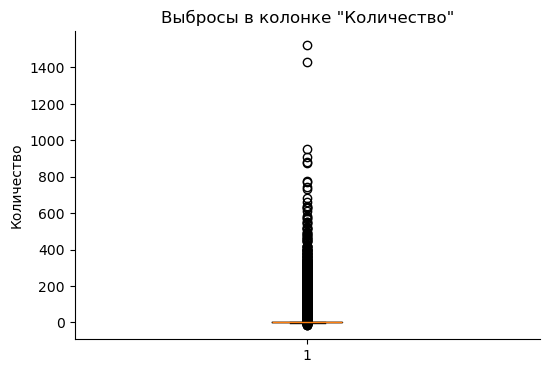

In [16]:
# Выбросы в колонке "Количество"
plt.figure(figsize=(6, 4))
plt.boxplot(df['Количество'].dropna())
plt.title('Выбросы в колонке "Количество"')
plt.ylabel('Количество')
plt.show()

In [17]:
# Фильтры
df = df[df['ОстатокНачалоНедели'] % 1 == 0]
df = df[df['Количество'] >= 0]
df['НеделяНачало'] = pd.to_datetime(df['НеделяНачало'])

In [18]:
df = df[df['Папка1'] != 'разобрать']
df = df[df['ЕдиницаИзмерения'] == 'шт']
df = df[df['ТоварнаяКатегория'] == 'Штучный товар']
df = df[df['Номенклатура'] != '1']
df = df[df['НеделяНачало'] > '2021-01-01']

print(f'Строк: {len(df):,}')
print(f'Уникальных товаров: {df["КодТовара"].nunique():,}')
print(f'Уникальных недель: {df["НеделяНачало"].nunique()}')

Строк: 1,894,913
Уникальных товаров: 29,455
Уникальных недель: 252


In [19]:
df.head()

,НеделяНачало,КодТовара,Номенклатура,Папка1,Папка2,Количество,Розничная30%,ЕдиницаИзмерения,ТоварнаяКатегория,Поставщик,ЗакупочнаяЦена,ДатаПоследнегоПоступления,ОстатокНачалоНедели,temp_mean_week,precip_sum_week,temp_max_week,temp_min_week,НДС,days_off_in_week,sales_lag_2w
574000,2021-01-04,00-00000104,Фитоспорин универсальный 10г.,01 Химия для сада и огорода,03 Средства от болезней растений,0.0,15.0,шт,Штучный товар,"ИП Алексеев Н.С, ПЕНЗА САДОВИТА",10.08,2020-03-15 09:11:15,1.0,-7.171429,22.1,0.6,-17.8,0.2,5,0.0
574001,2021-01-04,00-00000038,Гумат+7 йод 25г.,01 Химия для сада и огорода,"01 Жидкие удобрения, стимуляторы, подкормки",0.0,13.0,шт,Штучный товар,Колхоз,9.20,2020-12-05 10:03:24,20.0,-7.171429,22.1,0.6,-17.8,0.2,5,0.0
574002,2021-01-04,00-00000043,"Крепень 1,5мл. Чтобы рассада не переростала.",01 Химия для сада и огорода,"01 Жидкие удобрения, стимуляторы, подкормки",3.0,10.0,шт,Штучный товар,Колхоз,6.62,2020-05-21 10:50:47,56.0,-7.171429,22.1,0.6,-17.8,0.2,5,0.0
574003,2021-01-04,00-00000048,Проросток 1мл. Стимулятор иммунитета растений.,01 Химия для сада и огорода,"01 Жидкие удобрения, стимуляторы, подкормки",0.0,22.0,шт,Штучный товар,"ИП Алексеев Н.С, ПЕНЗА САДОВИТА",15.21,2020-10-07 13:25:48,48.0,-7.171429,22.1,0.6,-17.8,0.2,5,0.0
574004,2021-01-04,00-00000062,Циркон регулятор роста 1мл.,01 Химия для сада и огорода,"01 Жидкие удобрения, стимуляторы, подкормки",2.0,15.0,шт,Штучный товар,Новый Магазин,9.87,2020-12-09 13:38:07,35.0,-7.171429,22.1,0.6,-17.8,0.2,5,0.0


In [20]:
# Доля нулей
q = df['Количество']
share_zero = (q == 0).mean()
print(f'Строк с Количество == 0: {(q == 0).sum():,} ({share_zero*100:.1f}%)')

Строк с Количество == 0: 1,415,137 (74.7%)


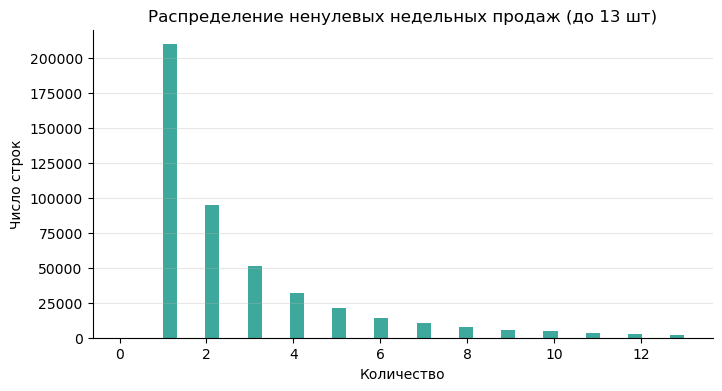

In [21]:
# Гистограмма ненулевых продаж до 99-го перцентиля
cap99 = q.quantile(0.99)
plt.figure(figsize=(8, 4))
plt.hist(q[(q > 0) & (q <= cap99)], bins=40, color='#3DA89B')
plt.title(f'Распределение ненулевых недельных продаж (до {cap99:.0f} шт)')
plt.xlabel('Количество')
plt.ylabel('Число строк')
plt.grid(axis='y', alpha=0.3)
plt.show()

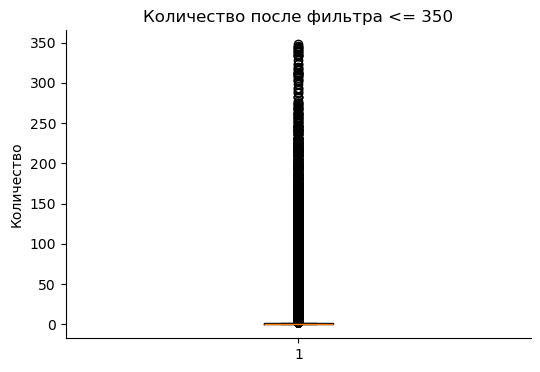

In [22]:
# Boxplot после применения кап=350
plt.figure(figsize=(6, 4))
plt.boxplot(q[q <= 350])
plt.title('Количество после фильтра <= 350')
plt.ylabel('Количество')
plt.show()

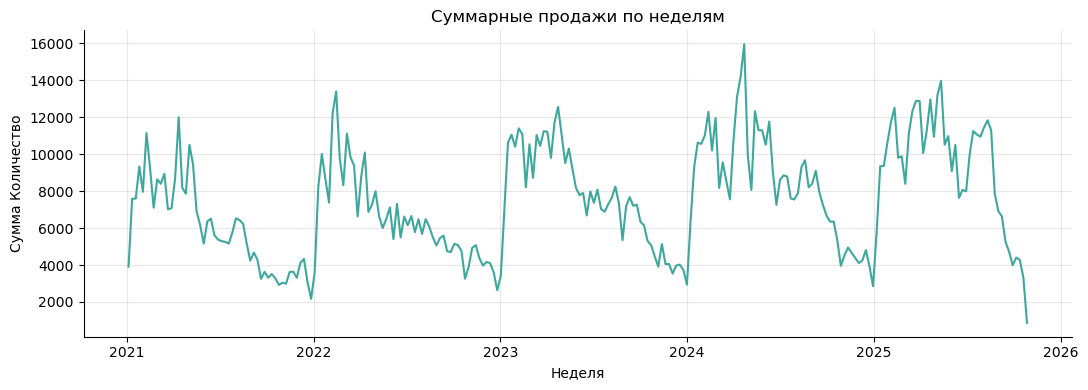

In [23]:
# Суммарные продажи по неделям
ts = df.groupby('НеделяНачало')['Количество'].sum()
plt.figure(figsize=(11, 4))
plt.plot(ts.index, ts.values, color='#3DA89B')
plt.title('Суммарные продажи по неделям')
plt.xlabel('Неделя')
plt.ylabel('Сумма Количество')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

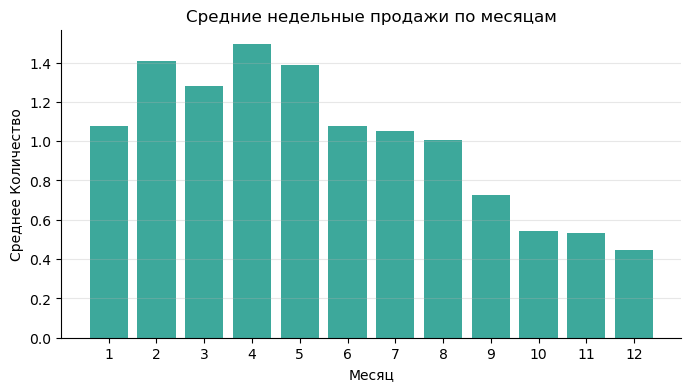

In [24]:
# Средние недельные продажи по месяцам
df['month_num'] = df['НеделяНачало'].dt.month
seasonal = df.groupby('month_num')['Количество'].mean()

plt.figure(figsize=(8, 4))
plt.bar(seasonal.index, seasonal.values, color='#3DA89B')
plt.title('Средние недельные продажи по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Среднее Количество')
plt.xticks(range(1, 13))
plt.grid(axis='y', alpha=0.3)
plt.show()

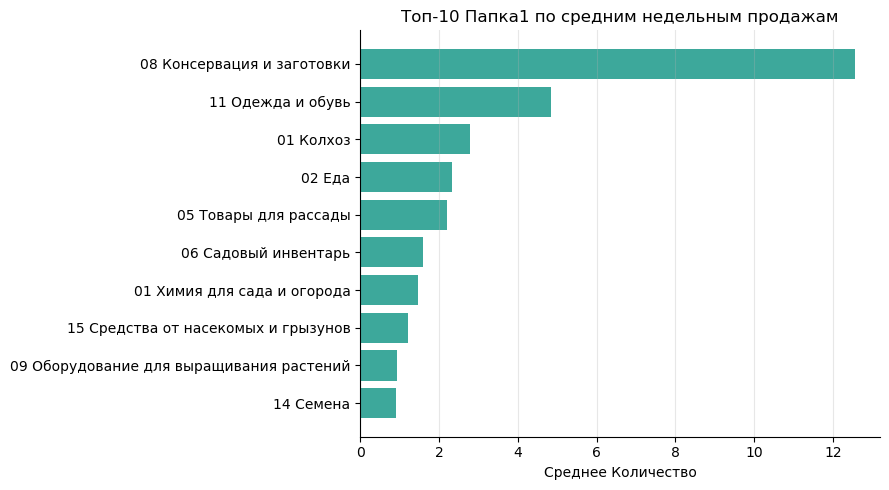

In [25]:
# Топ-10 Папка1 по среднему Количеству
top_mean = df.groupby('Папка1')['Количество'].mean().sort_values().tail(10)

plt.figure(figsize=(9, 5))
plt.barh([s[:40] for s in top_mean.index], top_mean.values, color='#3DA89B')
plt.title('Топ-10 Папка1 по средним недельным продажам')
plt.xlabel('Среднее Количество')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

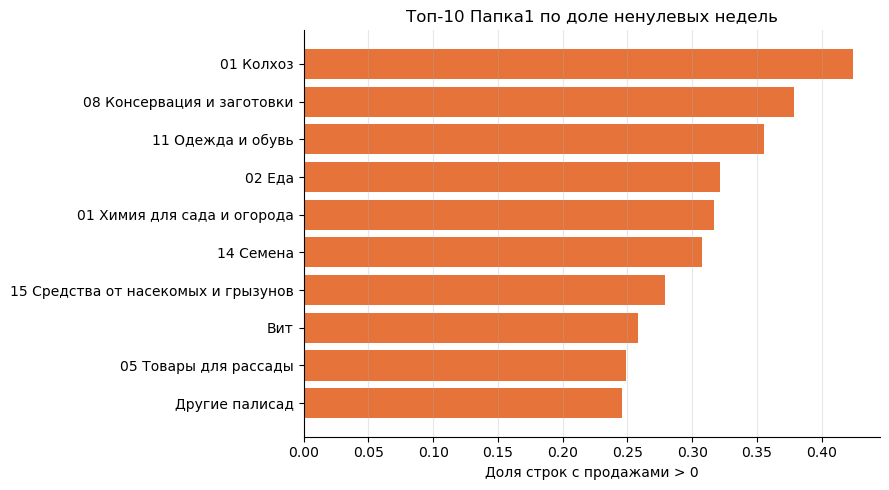

In [26]:
# Доля ненулевых недель по Папка1 (насколько активна категория)
active = df.groupby('Папка1')['Количество'].apply(lambda x: (x > 0).mean()).sort_values().tail(10)

plt.figure(figsize=(9, 5))
plt.barh([s[:40] for s in active.index], active.values, color='#E5733A')
plt.title('Топ-10 Папка1 по доле ненулевых недель')
plt.xlabel('Доля строк с продажами > 0')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

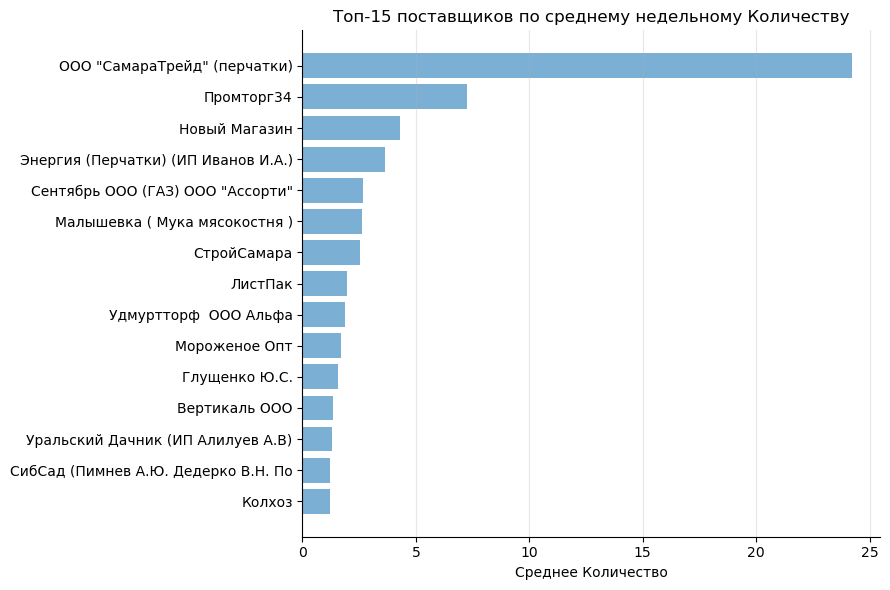

In [27]:
# Топ-15 поставщиков по среднему Количеству
top_sup = df.groupby('Поставщик')['Количество'].mean().sort_values().tail(15)

plt.figure(figsize=(9, 6))
plt.barh([s[:35] for s in top_sup.index], top_sup.values, color='#7BAFD4')
plt.title('Топ-15 поставщиков по среднему недельному Количеству')
plt.xlabel('Среднее Количество')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

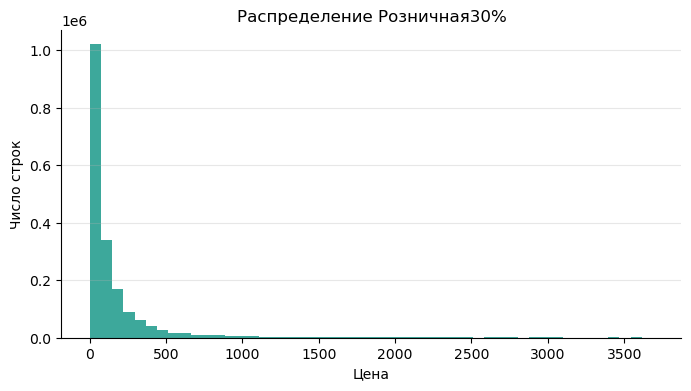

In [28]:
# Распределение Розничная30%
price = df['Розничная30%'].dropna()
p99   = price.quantile(0.99)
plt.figure(figsize=(8, 4))
plt.hist(price[price <= p99], bins=50, color='#3DA89B')
plt.title(f'Распределение Розничная30%')
plt.xlabel('Цена')
plt.ylabel('Число строк')
plt.grid(axis='y', alpha=0.3)
plt.show()

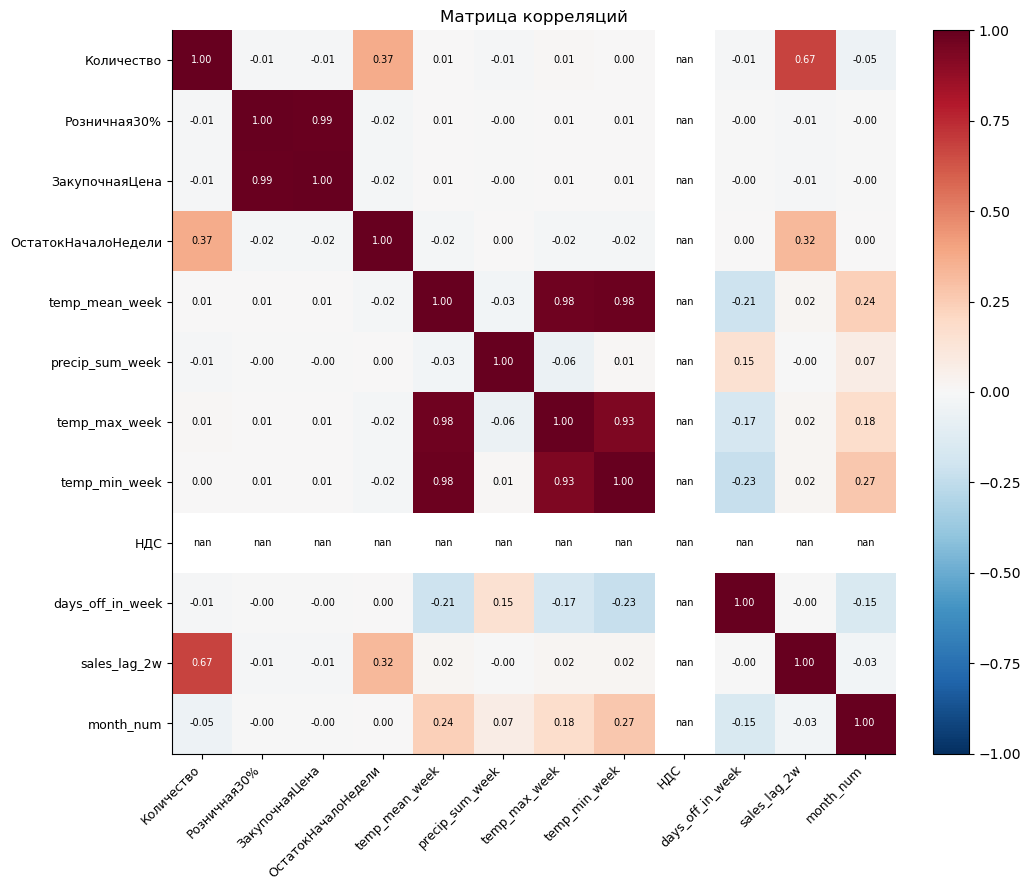

In [31]:
# Матрица корреляций
num_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(num_cols, fontsize=9)

# Значения в ячейках
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        v = corr.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                color='white' if abs(v) > 0.5 else 'black', fontsize=7)

ax.set_title('Матрица корреляций')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()